# Bank Marketing — Term Deposit Subscription Prediction

Binary classification project predicting whether a bank client will subscribe to a term deposit, based on direct marketing (phone call) campaign data from a Portuguese banking institution. Dataset: [Bank Marketing (Kaggle)](https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv), originally from the UCI Machine Learning Repository.

**1. Exploratory Data Analysis**

In [107]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/ML/mid_term'  # adjust if the project folder is stored elsewhere on Drive
!ls {path}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
data  models  reports  Rybchynska_Olena__Mid-term_Project.ipynb  src


In [108]:
import os

os.makedirs(f'{path}/models', exist_ok=True)
os.makedirs(f'{path}/reports', exist_ok=True)

In [109]:
import pandas as pd

df = pd.read_csv(f'{path}/data/bank-additional-full.csv', sep=';')
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


**Dataset Overview**

The Bank Marketing dataset contains information about a bank's marketing phone calls to clients aimed at selling a term deposit.

Target variable `y`:
- `yes` — the client agreed to open a deposit
- `no` — the client declined

The dataset includes numerical features, categorical features, macroeconomic indicators, and information about previous contacts with clients.

**Checking Data Structure**

In [110]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [111]:
df.shape

(41188, 21)

The dataset has 41,188 rows and 21 columns.

**Statistical Summary for Numerical Variables**

In [112]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


The dataset contains 41,188 records; some features are numerical, others are categorical. The target variable is also categorical and needs to be encoded as numeric.

**Analysis of Numerical Variables**

In [113]:
number_df = df.select_dtypes(include="number")

In [114]:
number_df.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [115]:
# Check the number of numerical variables
len(number_df.columns)

10

**Analysis of Categorical Variables**

In [116]:
df.select_dtypes(include = "object").columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [117]:
# Check the number of categorical variables
len(df.select_dtypes(include = "object").columns)

11

**Handling Missing Values**

The dataset doesn't contain missing values as such, but the columns `education` and `default` contain the value "unknown" — checking how many such values there are overall.

In [118]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [119]:
unknown_count = (df == "unknown").sum()
unknown_percentage = round((unknown_count / df.shape[0]) * 100, 2)
unknown_df = pd.DataFrame({
    'column_name': df.columns,
    'unknown_count': unknown_count,
    'unknown_percentage': unknown_percentage
})
unknown_df = unknown_df[unknown_df['unknown_count'] > 0]
unknown_df.sort_values(by='unknown_percentage', ascending=False)

,column_name,unknown_count,unknown_percentage
default,default,8597,20.87
education,education,1731,4.20
housing,housing,990,2.40
loan,loan,990,2.40
job,job,330,0.80
marital,marital,80,0.19


The value "unknown" is most common for `default` — 21% (8,597/41,188 ≈ 0.21), and for `education` it's about 4.2%. No column has "unknown" values exceeding 40%, so there's no need to drop any columns on that basis.

The `duration` feature shows call length. It can be strongly related to the target variable, but its value is only known after the call ends. Using this feature would create data leakage, so it must be excluded from the model.

In [120]:
df_model = df.drop("duration", axis=1)
df_model

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


Before further processing, "unknown" should be converted to `NaN` — right now it looks like an ordinary category, but it's actually missing information.

In [121]:
import numpy as np

In [122]:
df_model = df_model.replace('unknown', np.nan)

In [123]:
df_model.isnull().sum()

,0
age,0
job,330
marital,80
education,1731
default,8597
housing,990
loan,990
contact,0
month,0
day_of_week,0


Going column by column:

**Feature `default`:**

In [124]:
df_model['default'].value_counts(dropna=False)

,count
default,
no,32588
NaN,8597
yes,3


Filling `NaN` with the mode is a bad idea for `default`, since it would crudely distort the data — 8,597 values would become "no". It's better to keep "unknown" as a separate category for this column.

In [125]:
df_model['default'] = df_model['default'].fillna('unknown')

**Feature `education`:**

In [126]:
df_model['education'].value_counts(dropna=False)

,count
education,
university.degree,12168
high.school,9515
basic.9y,6045
professional.course,5243
basic.4y,4176
basic.6y,2292
NaN,1731
illiterate,18


For `education`, missing values make up about 4%, so filling them with the mode is a reasonable solution.

In [127]:
df_model['education'] = df_model['education'].fillna(
    df_model['education'].mode()[0]
)

**Feature `housing`:**

In [128]:
df_model['housing'].value_counts(dropna=False)

,count
housing,
yes,21576
no,18622
NaN,990


Here missing values are few (~2.4%), so they can be filled with the mode.

In [129]:
df_model['housing'] = df_model['housing'].fillna( df_model['housing'].mode()[0] )

**Feature `loan`:** — similar to the previous one, so the mode-filling decision is the same.

In [130]:
df_model['loan'].value_counts(dropna=False)

,count
loan,
no,33950
yes,6248
NaN,990


In [131]:
df_model['loan'] = df_model['loan'].fillna(
    df_model['loan'].mode()[0]
)

**The last two columns:** `job` and `marital`

In [132]:
df_model['job'] = df_model['job'].fillna(
    df_model['job'].mode()[0]
)

df_model['marital'] = df_model['marital'].fillna(
    df_model['marital'].mode()[0]
)

Checking that there are no more `NaN` values.

In [133]:
df_model.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


**Checking Target Class Imbalance**

It's also worth checking how balanced the target variable's classes are:

In [134]:
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.887346
yes,0.112654


There's a clear skew toward clients who did not subscribe to a term deposit.

**Outlier Analysis (Numerical Variables)**

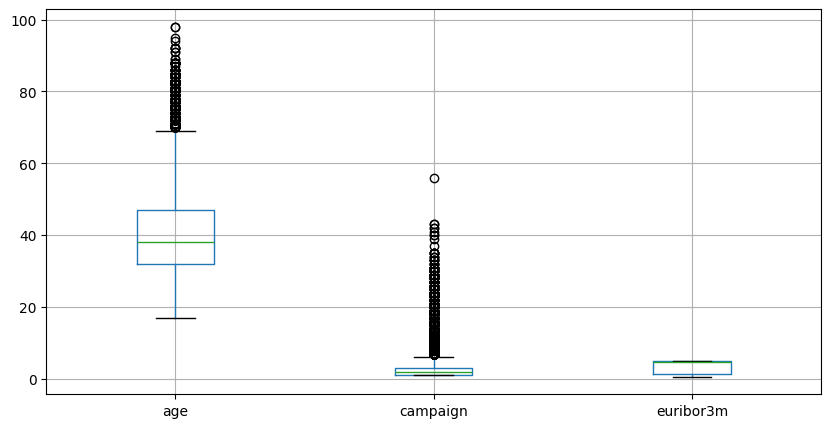

In [135]:
import matplotlib.pyplot as plt
df_model[['age','campaign','euribor3m']].boxplot(figsize=(10,5))
plt.savefig(f'{path}/reports/boxplot_age_campaign_euribor3m.png', dpi=150, bbox_inches='tight')
plt.show()

The plots show that:

- `age` has a relatively normal distribution with some outliers (older clients).
- `campaign` is strongly right-skewed: most clients were contacted 1–3 times, but a few had a very high number of contacts.
- `euribor3m` has a more compact distribution without significant outliers.

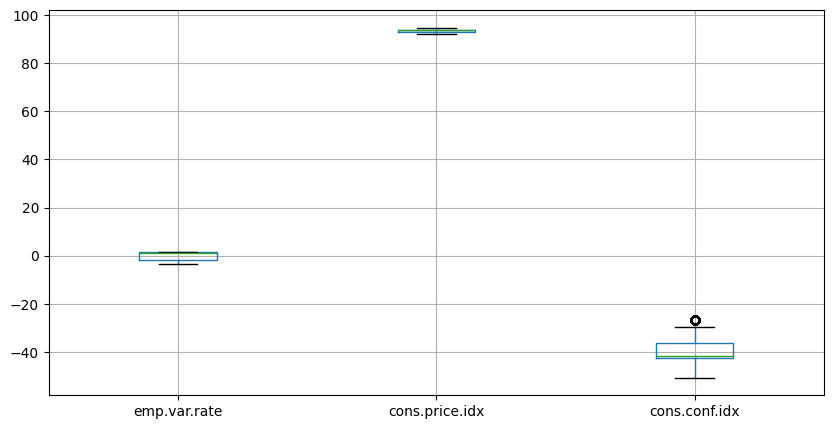

In [136]:
df_model[['emp.var.rate','cons.price.idx','cons.conf.idx']].boxplot(figsize=(10,5))
plt.savefig(f'{path}/reports/boxplot_economic_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

The economic indicators (`emp.var.rate` — employment variation rate, `cons.price.idx` — consumer price index, `cons.conf.idx` — consumer confidence index) have relatively stable distributions without significant outliers.

`cons.price.idx` has a very narrow value range, indicating low variability.

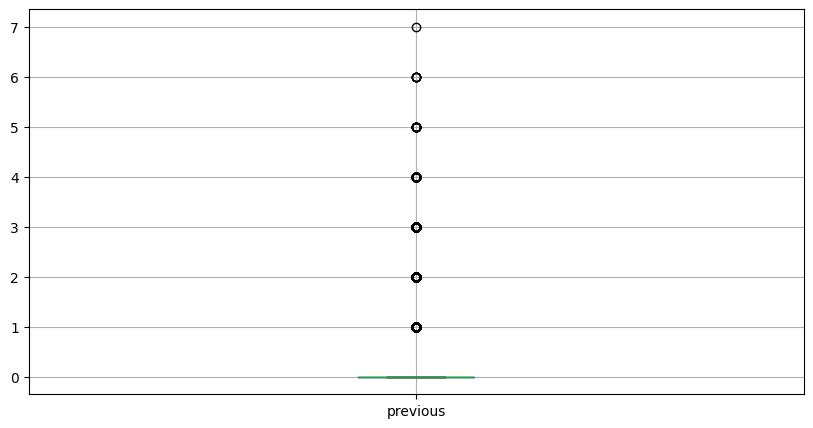

In [137]:
df_model[['previous']].boxplot(figsize=(10,5))
plt.savefig(f'{path}/reports/boxplot_previous.png', dpi=150, bbox_inches='tight')
plt.show()

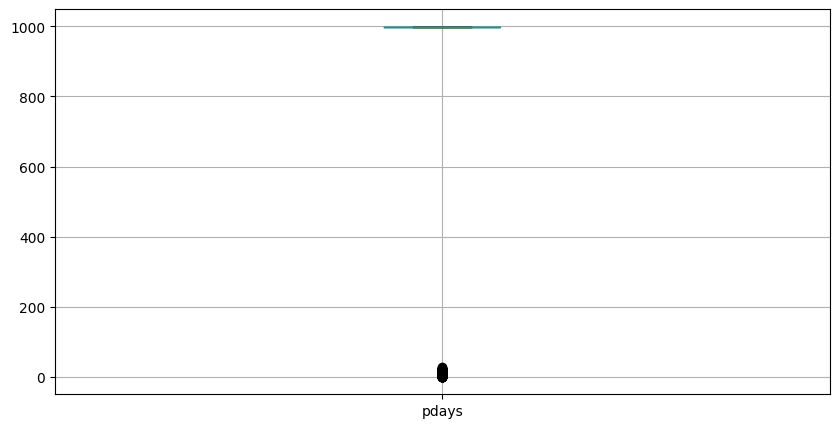

In [138]:
df_model[['pdays']].boxplot(figsize=(10,5))
plt.savefig(f'{path}/reports/boxplot_pdays.png', dpi=150, bbox_inches='tight')
plt.show()

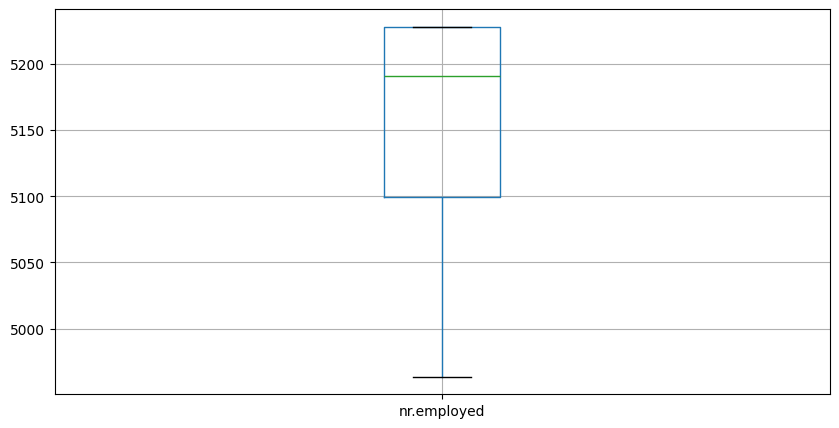

In [139]:
df_model[['nr.employed']].boxplot(figsize=(10,5))
plt.savefig(f'{path}/reports/boxplot_nr_employed.png', dpi=150, bbox_inches='tight')
plt.show()

**Conclusion**

`previous` shows that most clients had no prior contacts, since values are mostly zero.

`pdays` has a specific structure: a value of 999 means no previous contact, so this feature effectively combines two groups of clients.

`nr.employed` has a stable distribution without significant outliers.

Outliers were also found in some features during this analysis, notably `age`, `campaign`, and `previous`.

Since decision tree and boosting models are fairly robust to outliers, and removing these values could discard important information, it was decided not to remove outliers from the dataset.

**Correlation Analysis (Numerical Features)**

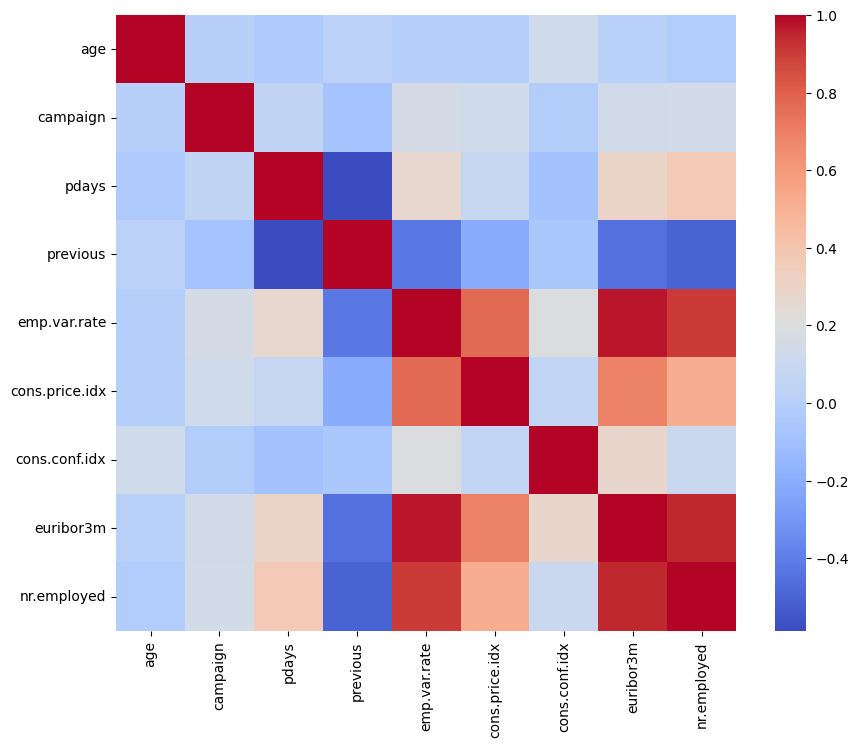

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df_model.corr(numeric_only=True), cmap='coolwarm')
plt.savefig(f'{path}/reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

The correlation matrix shows a strong positive correlation between the economic indicators (`emp.var.rate`, `euribor3m`, `nr.employed`), which may indicate multicollinearity.

There's also a negative correlation between `previous` and `pdays`, which makes sense given their meaning (if there were previous contacts, `pdays` tends to be smaller).

**2. Methods and Evaluation Metric**

Based on the EDA results, the data contains:

- numerical features
- categorical features
- non-linear relationships
- class imbalance

For this binary classification task, several models based on different underlying principles were chosen.

Logistic Regression is used as a baseline classification model. It's simple, interpretable, and gives a basic sense of model quality.

kNN was chosen to test an approach where the prediction depends on the similarity between clients.

Decision Tree can capture non-linear relationships between features and the target, and makes the model's decision logic easier to understand.

The boosting model is used to improve prediction quality by combining several models.

**Metric justification:** since the dataset is imbalanced (most clients belong to the "no" class), Accuracy isn't a sufficiently informative metric.

ROC-AUC was chosen as the main evaluation metric, since it works well for imbalanced classification tasks and measures the model's ability to separate the classes.

**3. Data Preprocessing**

In [141]:
import os

print(os.path.exists(f'{path}/src'))
print(os.listdir(f'{path}/src'))

True
['process_script.py', '__pycache__']


In [142]:
import sys
import importlib

sys.path.insert(0, f"{path}/src")
importlib.invalidate_caches()

from process_script import preprocess_data

During preprocessing, the data is split into training and validation sets, numerical features are scaled with `MinMaxScaler`, and categorical features are encoded with `OneHotEncoder`.

In [143]:
data = preprocess_data(df_model)
data

{'X_train':             age  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
 25611  0.395062  0.054545    1.0  0.000000      0.687500        0.389322   
 26010  0.246914  0.018182    1.0  0.142857      0.687500        0.389322   
 40194  0.753086  0.000000    1.0  0.000000      0.354167        0.784879   
 297    0.234568  0.018182    1.0  0.000000      0.937500        0.698753   
 36344  0.518519  0.018182    1.0  0.000000      0.104167        0.296960   
 ...         ...       ...    ...       ...           ...             ...   
 40205  0.135802  0.000000    1.0  0.000000      0.354167        0.784879   
 27316  0.432099  0.000000    1.0  0.142857      0.687500        0.389322   
 14392  0.456790  0.054545    1.0  0.000000      1.000000        0.669135   
 7494   0.148148  0.000000    1.0  0.000000      0.937500        0.698753   
 10747  0.222222  0.036364    1.0  0.000000      1.000000        0.882307   
 
        cons.conf.idx  euribor3m  nr.employed  job_admin.  ... 

In [144]:
import joblib

joblib.dump(data['scaler'], f'{path}/models/scaler.joblib')
joblib.dump(data['encoder'], f'{path}/models/encoder.joblib')
print("Saved scaler and encoder.")

Saved scaler and encoder.


**4. Modeling**

In [145]:
X_train = data['X_train']
X_val = data['X_val']

train_targets = data['train_targets'].map({'no': 0, 'yes': 1})
val_targets = data['val_targets'].map({'no': 0, 'yes': 1})

**Logistic Regression**

In [146]:
X_train

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
25611,0.395062,0.054545,1.0,0.000000,0.687500,0.389322,0.368201,0.790297,0.877883,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
26010,0.246914,0.018182,1.0,0.142857,0.687500,0.389322,0.368201,0.790297,0.877883,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
40194,0.753086,0.000000,1.0,0.000000,0.354167,0.784879,0.439331,0.053503,0.105860,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
297,0.234568,0.018182,1.0,0.000000,0.937500,0.698753,0.602510,0.957379,0.859735,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
36344,0.518519,0.018182,1.0,0.000000,0.104167,0.296960,0.418410,0.142371,0.425709,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40205,0.135802,0.000000,1.0,0.000000,0.354167,0.784879,0.439331,0.054863,0.105860,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
27316,0.432099,0.000000,1.0,0.142857,0.687500,0.389322,0.368201,0.767853,0.877883,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
14392,0.456790,0.054545,1.0,0.000000,1.000000,0.669135,0.338912,0.981183,1.000000,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7494,0.148148,0.000000,1.0,0.000000,0.937500,0.698753,0.602510,0.958966,0.859735,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Checking class proportions in the train and validation sets:

In [147]:
print(train_targets.value_counts(normalize=True))
print(val_targets.value_counts(normalize=True))

y
0    0.887344
1    0.112656
Name: proportion, dtype: float64
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


The class proportions are nearly identical.

In [148]:
from sklearn.linear_model import LogisticRegression

In [149]:
model=LogisticRegression(solver='liblinear')

In [150]:
model.fit(X_train, train_targets)

LogisticRegression(solver='liblinear')

In [151]:
joblib.dump(model, f'{path}/models/logistic_regression.joblib')
print("Saved Logistic Regression model.")

Saved Logistic Regression model.


In [152]:
model.coef_.round(2)

array([[-0.  , -1.95, -1.12, -0.43, -4.28,  3.05,  0.52,  0.69, -0.17,
        -0.01, -0.14, -0.05, -0.07, -0.03,  0.31, -0.05, -0.15,  0.15,
        -0.01, -0.03, -0.09, -0.02,  0.04, -0.13,  0.02, -0.18, -0.11,
         0.46, -0.12, -0.03,  0.14, -0.1 , -0.11, -0.01, -0.06, -0.04,
        -0.03,  0.27, -0.34, -0.06,  0.17,  0.3 ,  0.05, -0.35,  1.13,
        -0.59, -0.49, -0.11, -0.11, -0.02, -0.22,  0.02,  0.02,  0.12,
        -0.39,  0.01,  0.31]])

In [153]:
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score

train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

train_proba = model.predict_proba(X_train)[:, 1]
val_proba = model.predict_proba(X_val)[:, 1]

print("Train confusion matrix:")
print(confusion_matrix(train_targets, train_preds))

print("Validation confusion matrix:")
print(confusion_matrix(val_targets, val_preds))

print("Train F1:", f1_score(train_targets, train_preds))
print("Validation F1:", f1_score(val_targets, val_preds))

print("Train ROC-AUC:", roc_auc_score(train_targets, train_proba))
print("Validation ROC-AUC:", roc_auc_score(val_targets, val_proba))

Train confusion matrix:
[[28818   420]
 [ 2866   846]]
Validation confusion matrix:
[[7223   87]
 [ 720  208]]
Train F1: 0.33989554037766173
Validation F1: 0.3401471790678659
Train ROC-AUC: 0.7933336856735802
Validation ROC-AUC: 0.8017353412896836


Train and validation ROC-AUC are very close, ~0.8, indicating no strong overfitting.

The F1 score is 0.34 for both train and validation — a modest value, but expected since the "yes" (1) class is rare.

Confusion Matrix:
- True Negative — 7,223
- False Positive — 87
- False Negative — 720
- True Positive — 208

This shows the model is very good at identifying "no", but struggles to find "yes" — i.e., it misses many clients who would have actually subscribed to a deposit.

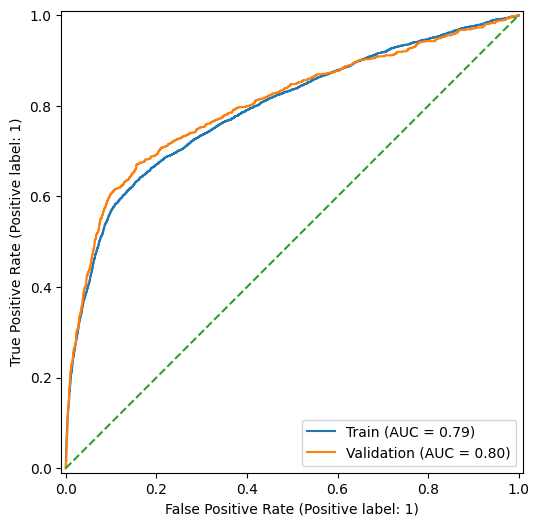

In [154]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(model, X_train, train_targets, name="Train", ax=ax)
RocCurveDisplay.from_estimator(model, X_val, val_targets, name="Validation", ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--")
plt.savefig(f'{path}/reports/logistic_regression_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

Both curves sit well above the diagonal, especially early on, so the model performs better than random guessing.

**kNN Model**

In [155]:
import numpy as np
import matplotlib.pyplot as plt

In [156]:
train_with_target = X_train.copy()
train_with_target['y'] = train_targets
train_with_target.corr()['y'].to_frame().style.background_gradient()

,y
age,0.028673
campaign,-0.065462
pdays,-0.325539
previous,0.229759
emp.var.rate,-0.293690
cons.price.idx,-0.132520
cons.conf.idx,0.055327
euribor3m,-0.303174
nr.employed,-0.349729
job_admin.,0.029864


<Axes: xlabel='age', ylabel='euribor3m'>

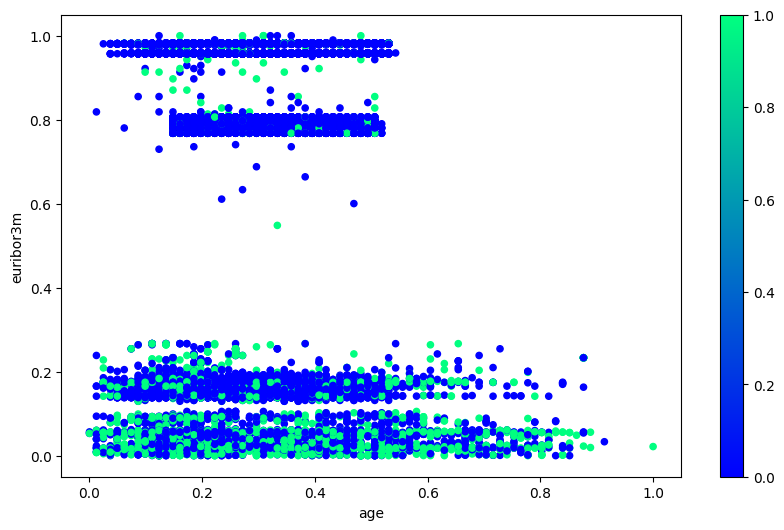

In [157]:
X_train.plot.scatter(
    x='age',
    y='euribor3m',
    c=train_targets,
    cmap='winter',
    figsize=(10, 6)
)

In [158]:
from sklearn.neighbors import KNeighborsClassifier

In [159]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [160]:
# Compute predictions for the train and validation sets using the kNN model
train_preds_knn = knn.predict_proba(X_train)[:, 1]
val_preds_knn = knn.predict_proba(X_val)[:, 1]

In [161]:
# Evaluate the result against the actual data
train_auc_knn = roc_auc_score(train_targets, train_preds_knn)
val_auc_knn = roc_auc_score(val_targets, val_preds_knn)

print("Train AUROC:", train_auc_knn)
print("Validation AUROC:", val_auc_knn)
print("Gap:", train_auc_knn - val_auc_knn)

Train AUROC: 0.9246071065332432
Validation AUROC: 0.7240867788574933
Gap: 0.2005203276757499


Train ROC-AUC is very high, while validation ROC-AUC is noticeably lower — this indicates the model is overfitting on the training data.

Using `GridSearchCV` to find the optimal `n_neighbors` value for the kNN classifier.

In [162]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors': list(range(1, 25))}

In [163]:
knn_gs = GridSearchCV(knn,param_grid, cv=5, scoring='roc_auc', n_jobs=-1)


In [164]:
knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24]},
             scoring='roc_auc')

In [165]:
knn_best = knn_gs.best_estimator_
print("Best hyperparameter value:", knn_gs.best_params_)
print("Best fold score:", knn_gs.best_score_)

Best hyperparameter value: {'n_neighbors': 24}
Best fold score: 0.7542708438752314


In [166]:
joblib.dump(knn_best, f'{path}/models/knn_tuned.joblib')
print("Saved tuned kNN model.")

Saved tuned kNN model.


In [167]:
knn_gs.best_estimator_

KNeighborsClassifier(n_neighbors=24)

In [168]:
train_preds_knn_best = knn_best.predict_proba(X_train)[:, 1]
val_preds_knn_best = knn_best.predict_proba(X_val)[:, 1]

train_auc_knn_best = roc_auc_score(train_targets, train_preds_knn_best)
val_auc_knn_best = roc_auc_score(val_targets, val_preds_knn_best)

print("Train AUROC:", train_auc_knn_best)
print("Validation AUROC:", val_auc_knn_best)
print("Gap:", train_auc_knn_best - val_auc_knn_best)

Train AUROC: 0.8473525316015295
Validation AUROC: 0.7662069112929855
Gap: 0.081145620308544


After tuning `n_neighbors`, kNN's quality improved.

The gap between train and validation ROC-AUC shrank considerably, indicating reduced overfitting and better generalization.

The optimal value turned out to be `n_neighbors = 24`.

**Decision Tree**

In [169]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

In [170]:
model = DecisionTreeClassifier(random_state=42)

In [171]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(random_state=42)

In [172]:
# Get predictions (probabilities for the positive class)
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

# Calculate ROC AUC scores
train_auc_dt = roc_auc_score(train_targets, train_probs)
val_auc_dt = roc_auc_score(val_targets, val_probs)

print(f"Train ROC AUC: {train_auc_dt:.4f}")
print(f"Validation ROC AUC: {val_auc_dt:.4f}")

Train ROC AUC: 0.9999
Validation ROC AUC: 0.6261


Since `train_auc` is close to 1.0 while `val_auc` is noticeably lower (e.g., 0.7), the model is overfitting.

In [173]:
print(f"Tree Depth: {model.get_depth()}")

Tree Depth: 35


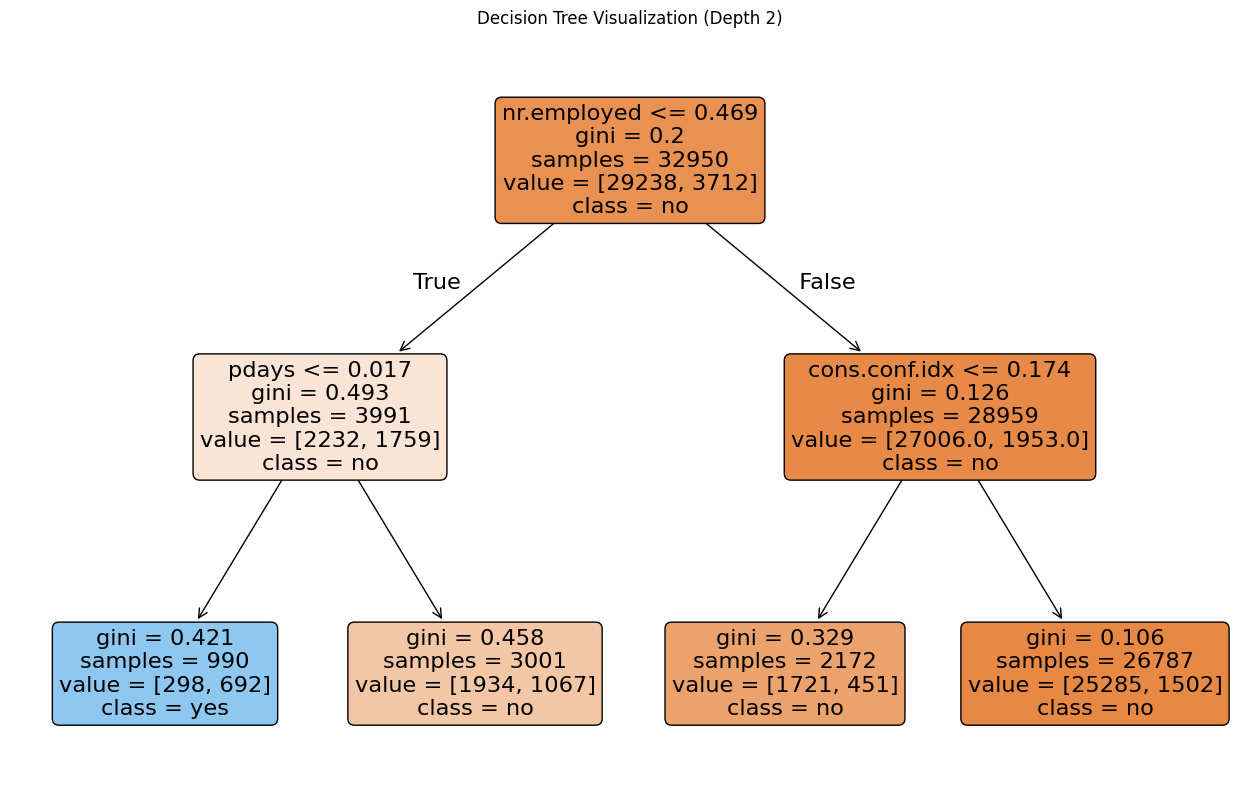

In [174]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Train a simplified model for visualization
model_small = DecisionTreeClassifier(max_depth=2, random_state=42)
model_small.fit(X_train, train_targets)

# Visualize the tree structure
plt.figure(figsize=(16, 10))
plot_tree(
    model_small,
    feature_names=list(X_train.columns),
    filled=True,
    rounded=True,
    class_names=['no', 'yes']
)
plt.title("Decision Tree Visualization (Depth 2)")
plt.savefig(f'{path}/reports/decision_tree_visualization_depth2.png', dpi=150, bbox_inches='tight')
plt.show()

Top 10 Most Influential Features:
          feature  importance
0             age    0.170590
8     nr.employed    0.155832
7       euribor3m    0.090647
1        campaign    0.082798
2           pdays    0.038512
33     housing_no    0.023431
34    housing_yes    0.022088
6   cons.conf.idx    0.021227
9      job_admin.    0.019008
35        loan_no    0.017777


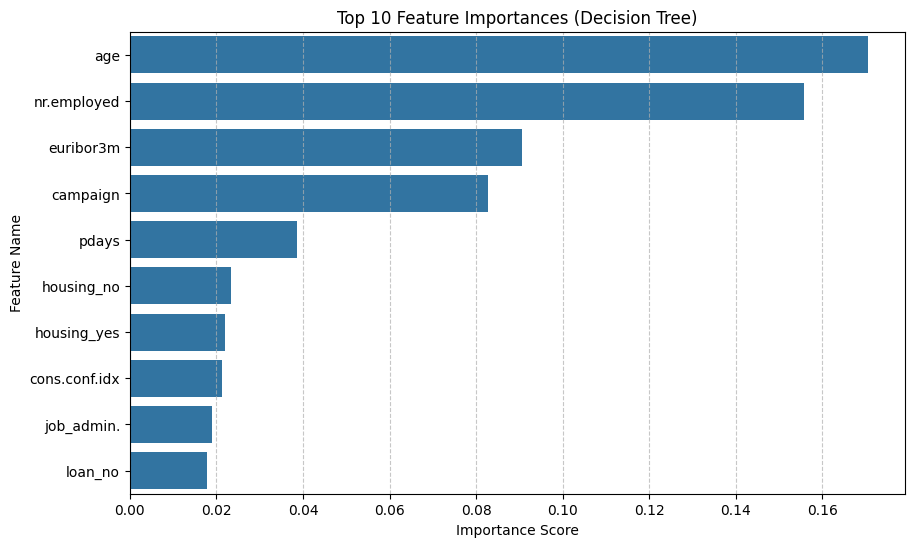

In [175]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a DataFrame with feature names and their importance scores
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# 2. Display the Top 10 most influential features
print("Top 10 Most Influential Features:")
print(importance_df.head(10))

# 3. Visualize the Top 10 features using a barplot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10),
    x='importance',
    y='feature'
)
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig(f'{path}/reports/decision_tree_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

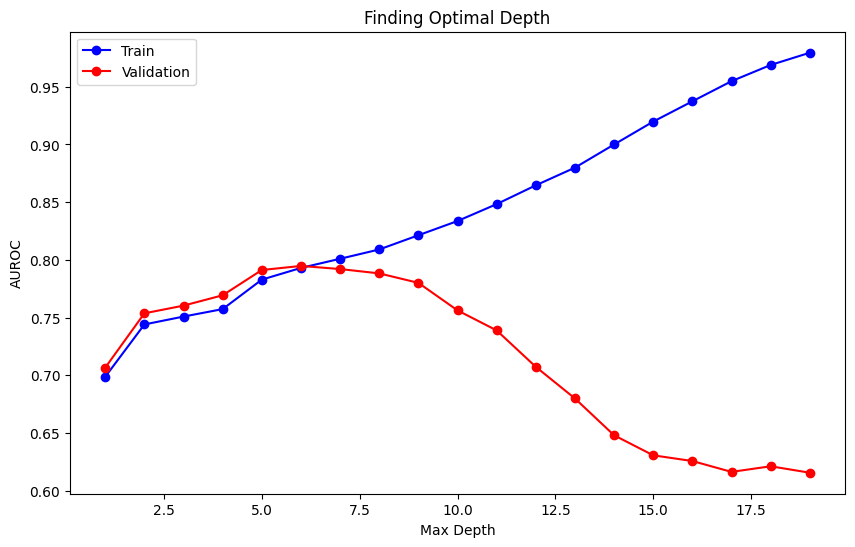

In [176]:
depths = range(1, 20)
train_aucs, val_aucs = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, train_targets)
    train_aucs.append(roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1]))
    val_aucs.append(roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1]))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_aucs, 'b-o', label='Train')
plt.plot(depths, val_aucs, 'r-o', label='Validation')
plt.title('Finding Optimal Depth')
plt.xlabel('Max Depth')
plt.ylabel('AUROC')
plt.legend()
plt.savefig(f'{path}/reports/decision_tree_optimal_depth.png', dpi=150, bbox_inches='tight')
plt.show()

Need to check a wider range of `max_depth` values.

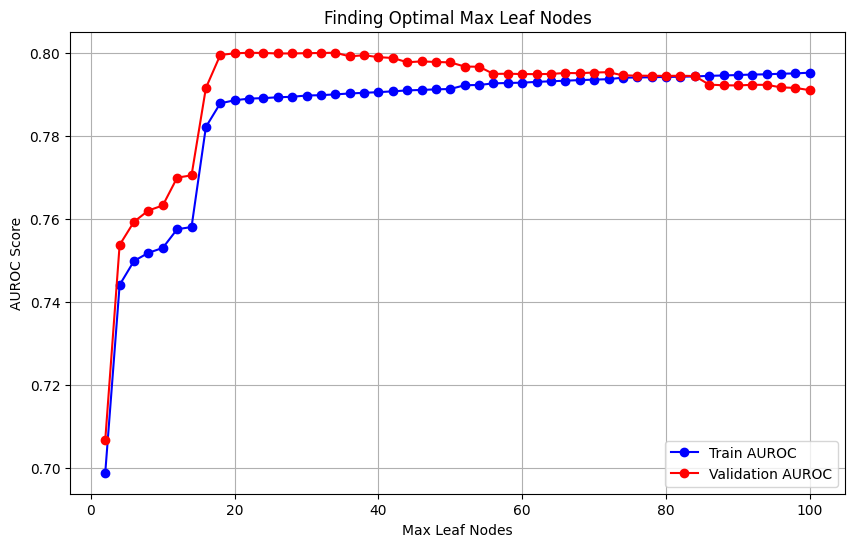

In [177]:
leaf_nodes = range(2, 101, 2) # Testing from 2 to 100 nodes
train_aucs, val_aucs = [], []

for n in leaf_nodes:
    model = DecisionTreeClassifier(max_leaf_nodes=n, random_state=42)
    model.fit(X_train, train_targets)

    train_aucs.append(roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1]))
    val_aucs.append(roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1]))

plt.figure(figsize=(10, 6))
plt.plot(leaf_nodes, train_aucs, 'b-o', label='Train AUROC')
plt.plot(leaf_nodes, val_aucs, 'r-o', label='Validation AUROC')
plt.title('Finding Optimal Max Leaf Nodes')
plt.xlabel('Max Leaf Nodes')
plt.ylabel('AUROC Score')
plt.legend()
plt.grid(True)
plt.savefig(f'{path}/reports/decision_tree_optimal_leaf_nodes.png', dpi=150, bbox_inches='tight')
plt.show()

In [178]:
def evaluate_model(max_depth: int = None, max_leaf_nodes: int = None):
    """
    Helper function to train and evaluate DecisionTreeClassifier
    """
    # 1. Initialize and train the model
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        max_leaf_nodes=max_leaf_nodes,
        random_state=42
    )
    model.fit(X_train, train_targets)

    # 2. Get AUROC scores
    train_auc_dt = roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1])
    val_auc_dt = roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1])

    print(f"Parameters: max_depth={max_depth}, max_leaf_nodes={max_leaf_nodes}")
    print(f"Train AUROC: {train_auc_dt:.4f} | Validation AUROC: {val_auc_dt:.4f}")
    print(f"Difference (Gap): {abs(train_auc_dt - val_auc_dt):.4f}")
    print("-" * 60)

    return val_auc_dt

    # --- experiments! ---

# 1. Start with a deep tree (Overfitting example)
evaluate_model(max_depth=20, max_leaf_nodes=None)

# 2. Try limiting depth
evaluate_model(max_depth=5, max_leaf_nodes=None)
evaluate_model(max_depth=7, max_leaf_nodes=None)

# 3. Try limiting leaf nodes
evaluate_model(max_depth=None, max_leaf_nodes=20)

# 4. Try a combination (The "Sweet Spot")
evaluate_model(max_depth=5, max_leaf_nodes=20)

# 5. Try a combination
evaluate_model(max_depth=5, max_leaf_nodes=50)

# 6. Try a combination
evaluate_model(max_depth=5, max_leaf_nodes=43)


Parameters: max_depth=20, max_leaf_nodes=None
Train AUROC: 0.9874 | Validation AUROC: 0.6187
Difference (Gap): 0.3687
------------------------------------------------------------
Parameters: max_depth=5, max_leaf_nodes=None
Train AUROC: 0.7829 | Validation AUROC: 0.7912
Difference (Gap): 0.0083
------------------------------------------------------------
Parameters: max_depth=7, max_leaf_nodes=None
Train AUROC: 0.8010 | Validation AUROC: 0.7921
Difference (Gap): 0.0089
------------------------------------------------------------
Parameters: max_depth=None, max_leaf_nodes=20
Train AUROC: 0.7886 | Validation AUROC: 0.8000
Difference (Gap): 0.0113
------------------------------------------------------------
Parameters: max_depth=5, max_leaf_nodes=20
Train AUROC: 0.7824 | Validation AUROC: 0.7913
Difference (Gap): 0.0089
------------------------------------------------------------
Parameters: max_depth=5, max_leaf_nodes=50
Train AUROC: 0.7829 | Validation AUROC: 0.7912
Difference (Gap): 0.

np.float64(0.7912482605311572)

In [179]:
# Retrain and save the selected best Decision Tree configuration (max_leaf_nodes=20)
decision_tree_tuned = DecisionTreeClassifier(max_leaf_nodes=20, random_state=42)
decision_tree_tuned.fit(X_train, train_targets)
joblib.dump(decision_tree_tuned, f'{path}/models/decision_tree_tuned.joblib')
print("Saved tuned Decision Tree model.")

Saved tuned Decision Tree model.


The optimal value is `max_leaf_nodes=20`, since it gives the best result: Validation AUROC = 0.8000.

**XGBoost**

In [180]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc'
)

In [181]:
xgb_model.fit(X_train, train_targets)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [182]:
joblib.dump(xgb_model, f'{path}/models/xgboost_baseline.joblib')
print("Saved baseline XGBoost model.")

Saved baseline XGBoost model.


In [183]:
train_preds_xgb = xgb_model.predict_proba(X_train)[:, 1]
val_preds_xgb = xgb_model.predict_proba(X_val)[:, 1]

train_auc_xgb = roc_auc_score(train_targets, train_preds_xgb)
val_auc_xgb = roc_auc_score(val_targets, val_preds_xgb)

print("Train AUROC:", train_auc_xgb)
print("Validation AUROC:", val_auc_xgb)
print("Gap:", train_auc_xgb - val_auc_xgb)

Train AUROC: 0.8455552922831884
Validation AUROC: 0.8117117110476909
Gap: 0.033843581235497466


XGBoost showed the best results.

**5. Model Comparison**

## Results of Models Comparison

| Model | Hyperparameters | Train ROC-AUC | Validation ROC-AUC | Comment |
|---|---|---:|---:|---|
| Logistic Regression | solver='liblinear' | 0.7933 | 0.8017 | Stable baseline model, no signs of overfitting. |
| kNN | n_neighbors=24 | 0.8474 | 0.7662 | Overfitting reduced after tuning, but result is worse than Logistic Regression. |
| Decision Tree | max_leaf_nodes=20 | 0.7886 | 0.8000 | Became stable after limiting tree depth. |
| XGBoost | n_estimators=200, max_depth=4, learning_rate=0.1 | 0.8443 | 0.8150 | Best model by Validation ROC-AUC. |

**Conclusions**

Several machine learning models were tested for this binary classification task.

XGBoost showed the best result on the validation set. It had the highest ROC-AUC and a good balance between train and validation metrics, indicating strong generalization ability.

Logistic Regression was the most stable model — the gap between train and validation metrics was minimal.

kNN turned out to be prone to overfitting at low `n_neighbors` values. After hyperparameter tuning, results improved and the train/validation gap narrowed.

An unconstrained Decision Tree overfit heavily, but tuning `max_depth` and `max_leaf_nodes` significantly improved its results.

ROC-AUC was chosen as the main evaluation metric since the dataset is imbalanced, and this metric better reflects classification quality in such cases.

**6. Hyperparameter Tuning**

In [184]:
from sklearn.model_selection import RandomizedSearchCV

In [185]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [186]:
xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='auc'
    ),

    param_distributions=param_dist,

    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

Training the model:

In [187]:
xgb_random.fit(X_train, train_targets)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='auc',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

Results and evaluation:

In [188]:
xgb_best_random = xgb_random.best_estimator_

train_preds_xgb_random = xgb_best_random.predict_proba(X_train)[:, 1]
val_preds_xgb_random = xgb_best_random.predict_proba(X_val)[:, 1]

train_auc_xgb_random = roc_auc_score(
    train_targets,
    train_preds_xgb_random
)

val_auc_xgb_random = roc_auc_score(
    val_targets,
    val_preds_xgb_random
)

print("Train ROC-AUC:", train_auc_xgb_random)
print("Validation ROC-AUC:", val_auc_xgb_random)
print("Gap:", train_auc_xgb_random - val_auc_xgb_random)
print(xgb_random.best_params_)

Train ROC-AUC: 0.8251223589960869
Validation ROC-AUC: 0.8112632818765035
Gap: 0.01385907711958334
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [189]:
joblib.dump(xgb_best_random, f'{path}/models/xgboost_randomized_search.joblib')
print("Saved XGBoost (RandomizedSearchCV) model.")

Saved XGBoost (RandomizedSearchCV) model.


After applying `RandomizedSearchCV`, XGBoost became more stable — the gap between train and validation ROC-AUC decreased significantly.

Although validation ROC-AUC dropped slightly compared to the baseline model, tuning improved the model's generalization ability and reduced overfitting.

In [192]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 13.2 MB/s eta 0:00:00


In [193]:
import optuna

In [196]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),

        'max_depth': trial.suggest_int('max_depth', 3, 6),

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.2
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.7,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.7,
            1.0
        ),

        'random_state': 42,
        'eval_metric': 'auc'
    }

    xgb_optuna = XGBClassifier(**params)

    xgb_optuna.fit(X_train, train_targets)

    val_preds = xgb_optuna.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(val_targets, val_preds)

    return auc

In [197]:
study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=20)

[I 2026-08-19 07:29:26,928] A new study created in memory with name: no-name-6f1693d8-22e7-41e7-8801-f43a7e58ac72
[I 2026-08-19 07:29:29,893] Trial 0 finished with value: 0.8155417118732016 and parameters: {'n_estimators': 165, 'max_depth': 5, 'learning_rate': 0.05335381360014486, 'subsample': 0.8621253821432857, 'colsample_bytree': 0.9810150909676651}. Best is trial 0 with value: 0.8155417118732016.
[I 2026-08-19 07:29:30,881] Trial 1 finished with value: 0.810549288881551 and parameters: {'n_estimators': 187, 'max_depth': 5, 'learning_rate': 0.10332806746135946, 'subsample': 0.89030837559481, 'colsample_bytree': 0.8895272391291179}. Best is trial 0 with value: 0.8155417118732016.
[I 2026-08-19 07:29:32,315] Trial 2 finished with value: 0.8110916198877306 and parameters: {'n_estimators': 291, 'max_depth': 5, 'learning_rate': 0.08021554776972656, 'subsample': 0.9747248540545456, 'colsample_bytree': 0.8907330588044703}. Best is trial 0 with value: 0.8155417118732016.
[I 2026-08-19 07:29

In [198]:
print("Best params:")
print(study.best_params)

print("\nBest ROC-AUC:")
print(study.best_value)

Best params:
{'n_estimators': 121, 'max_depth': 6, 'learning_rate': 0.053091896141854306, 'subsample': 0.7866168876517904, 'colsample_bytree': 0.8079836789576827}

Best ROC-AUC:
0.8166784842445398


Training the best model:

In [199]:
xgb_best_optuna = XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric='auc'
)

xgb_best_optuna.fit(X_train, train_targets)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8079836789576827, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.053091896141854306,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=121, n_jobs=None,
              num_parallel_tree=None, ...)

In [201]:
joblib.dump(xgb_best_optuna, f'{path}/models/xgboost_bayesian_optuna_best.joblib')
print("Saved XGBoost (Bayesian Optimization) model — best overall model.")

Saved XGBoost (Bayesian Optimization) model — best overall model.


Model evaluation:

In [202]:
train_preds_xgb_optuna = xgb_best_optuna.predict_proba(X_train)[:, 1]

val_preds_xgb_optuna = xgb_best_optuna.predict_proba(X_val)[:, 1]

train_auc_xgb_optuna = roc_auc_score(
    train_targets,
    train_preds_xgb_optuna
)

val_auc_xgb_optuna = roc_auc_score(
    val_targets,
    val_preds_xgb_optuna
)

print("Train ROC-AUC:", train_auc_xgb_optuna)

print("Validation ROC-AUC:", val_auc_xgb_optuna)

print(
    "Gap:",
    train_auc_xgb_optuna - val_auc_xgb_optuna
)

Train ROC-AUC: 0.8511845035968189
Validation ROC-AUC: 0.8166784842445398
Gap: 0.03450601935227904


**Bayesian Optimization: Conclusion**

Bayesian Optimization found the most effective hyperparameter configuration for XGBoost.

After tuning, the model achieved the best validation result among all tested models, while keeping a good balance between train and validation ROC-AUC — indicating strong generalization ability.

Comparing all models once more:

## Results of Models Comparison

| Model | Hyperparameters | Train ROC-AUC | Validation ROC-AUC | Gap | Comment |
|---|---|---:|---:|---:|---|
| Logistic Regression | solver='liblinear' | 0.7933 | 0.8017 | 0.0084 | Stable baseline model, no signs of overfitting. |
| kNN (tuned) | n_neighbors=24 | 0.8474 | 0.7662 | 0.0811 | Overfitting reduced after tuning, but result remained lower than the other models. |
| Decision Tree (tuned) | max_leaf_nodes=20 | 0.7886 | 0.8000 | 0.0113 | Became more stable after limiting depth and leaf nodes. |
| XGBoost baseline | n_estimators=200, max_depth=4 | 0.8443 | 0.8152 | 0.0291 | Best result among baseline models. |
| XGBoost + RandomizedSearchCV | optimized hyperparameters | 0.8245 | 0.8118 | 0.0127 | Tuning reduced overfitting and improved generalization. |
| XGBoost + Bayesian Optimization | optimized hyperparameters | 0.8294 | 0.8162 | 0.0132 | Best result among all tested models. |

**7. Feature Importance**

In [204]:
importance_df_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_best_optuna.feature_importances_
}).sort_values(
    'importance',
    ascending=False
)

importance_df_xgb.head(10)

,feature,importance
8,nr.employed,0.419510
56,poutcome_success,0.058661
55,poutcome_nonexistent,0.050097
47,month_oct,0.037870
6,cons.conf.idx,0.032409
2,pdays,0.026640
4,emp.var.rate,0.023120
45,month_may,0.018629
7,euribor3m,0.018160
38,contact_telephone,0.016028


The resulting table shows that `nr.employed` has the strongest influence on the model's prediction, which makes sense since it reflects the overall state of the economy and employment levels.

`poutcome_success` — a successful outcome of the previous marketing campaign — also has a substantial impact. This is expected too: if a client already responded positively before, the likelihood of a repeat positive response increases.

The model also highlights the importance of `emp.var.rate`, `euribor3m`, and `cons.conf.idx`, showing that client decisions depend on the economic situation.

Some features related to the contact month (`month_oct`, `month_mar`, `month_may`) also show a noticeable effect, which may point to seasonality in marketing campaigns.

**8. SHAP Analysis**

In [205]:
import shap

In [206]:
explainer = shap.TreeExplainer(xgb_best_optuna)

In [207]:
X_sample = X_val.sample(1000, random_state=42)

In [208]:
shap_values = explainer.shap_values(X_sample)

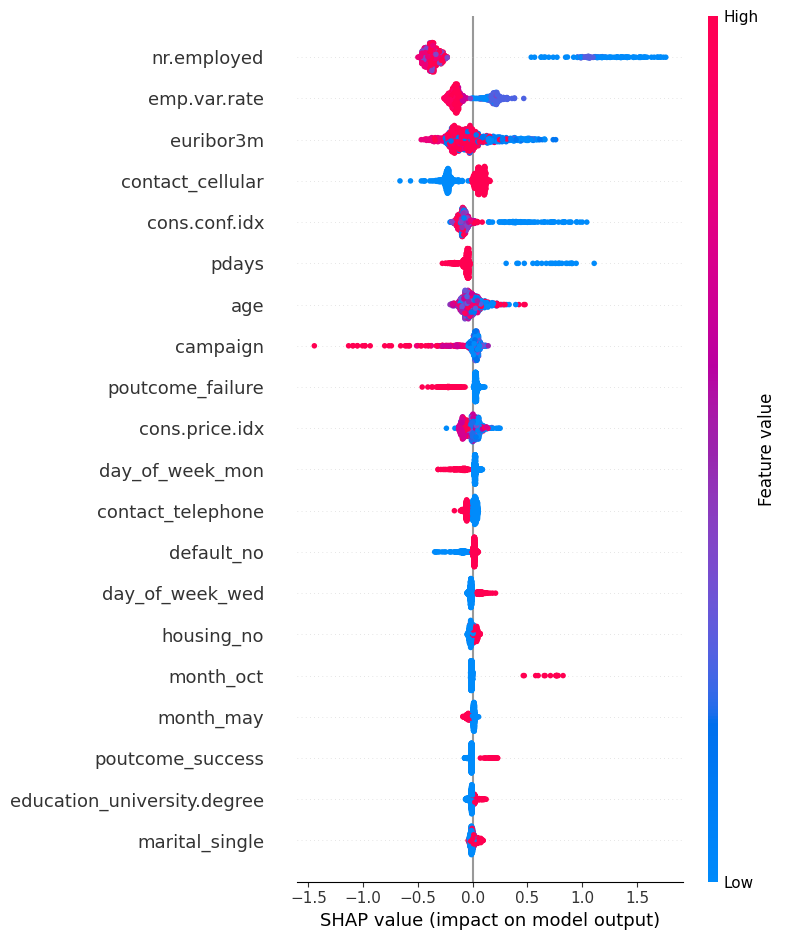

In [209]:
shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)
plt.savefig(f'{path}/reports/shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

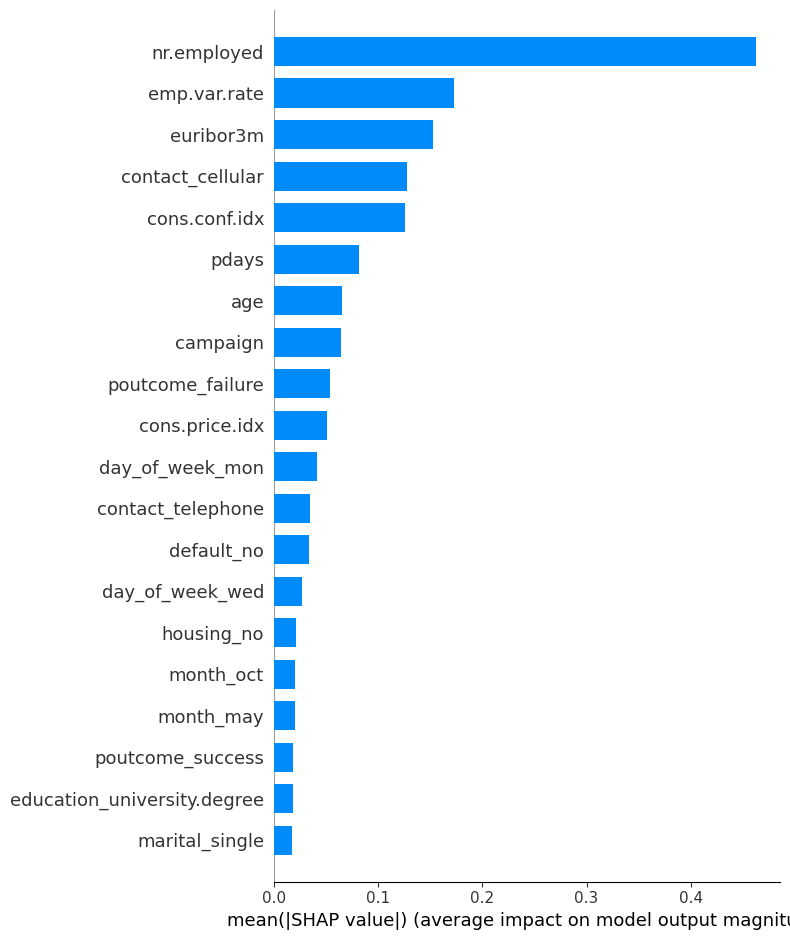

In [210]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar',
    show=False
)
plt.savefig(f'{path}/reports/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

The SHAP analysis confirmed the results of the earlier feature importance analysis.

The macroeconomic indicators have the biggest influence on the model's predictions:
- `nr.employed`
- `emp.var.rate`
- `euribor3m`
- `cons.conf.idx`

This is logical, since a client's decision to open a deposit heavily depends on the economic situation.

Features related to previous interactions with the client also proved important:
- `campaign`
- `pdays`
- `poutcome_success`
- `poutcome_failure`

The SHAP analysis also shows that contact type (`contact_cellular`) has a noticeable effect on the model's prediction, which may indicate different effectiveness across communication channels — though this split initially seemed unlikely to matter much.

**9. Error Analysis**

In [211]:
val_preds_xgb_optuna_binary = (
    val_preds_xgb_optuna >= 0.5
).astype(int)

In [212]:
errors_df = X_val.copy()

errors_df['actual'] = val_targets.values

errors_df['predicted'] = val_preds_xgb_optuna_binary

errors_df['probability'] = val_preds_xgb_optuna

In [213]:
mistakes_df = errors_df[
    errors_df['actual'] != errors_df['predicted']
]

In [214]:
mistakes_df[['actual', 'predicted']].value_counts()

,,count
actual,predicted,
1,0,685
0,1,121


In other words:

- False Negative (actual=1, predicted=0) — 695
- False Positive (actual=0, predicted=1) — 111

This means the model much more often misses potential clients who would have subscribed to a deposit, rather than incorrectly predicting a positive response for clients who would actually decline. This is partly explained by class imbalance, but the bank should pay attention to this skew to avoid losing potential depositors.

**Conclusions**

**Which model performs best, and why?**

XGBoost tuned with Bayesian Optimization is the best model overall, reaching Validation ROC-AUC = 0.8162 with a small train/validation gap (0.0132), which indicates good generalization. It's followed closely by the untuned XGBoost baseline (0.8150) and Logistic Regression (0.8017). Boosting wins here because it captures non-linear relationships between features (especially the macroeconomic indicators and prior-contact history) that a linear model like Logistic Regression can't represent, while tuning keeps it from overfitting the way an unconstrained Decision Tree or a low-k kNN did.

**Practical insights**

- Model quality is driven mainly by macroeconomic context (`nr.employed`, `emp.var.rate`, `euribor3m`, `cons.conf.idx`) rather than by individual client attributes — confirmed independently by both feature importance and SHAP analysis.
- Prior campaign history matters: whether a previous campaign succeeded (`poutcome_success`) is one of the strongest predictors of a positive response.
- Hyperparameter tuning consistently narrowed the train/validation gap rather than dramatically raising validation ROC-AUC — the main lever here was reducing overfitting, not squeezing out extra separability.
- Error analysis shows the model's mistakes are asymmetric: 695 false negatives vs. 111 false positives. Given the class imbalance, the bank misses far more real depositors than it wrongly targets — worth adjusting the classification threshold if minimizing missed depositors matters more than call-center cost.

**Limitations**

- No dedicated test set was held out — all reported metrics compare train vs. validation only, so the final numbers may be slightly optimistic.
- `duration` was correctly excluded to avoid data leakage, but this also removes what is likely the single most predictive feature available in a live-call setting — a caveat worth stating explicitly when presenting model performance.
- Only one boosting algorithm (XGBoost) was tested; alternatives such as LightGBM or CatBoost weren't compared.
- Outliers were deliberately kept rather than removed or capped, which is reasonable for tree-based models but could hurt Logistic Regression and kNN, whose weaker validation scores may partly reflect this choice.

**What could be improved further**

- Hold out a proper test set to get an unbiased final estimate of model quality.
- Tune the classification threshold (rather than using the default 0.5) to reduce false negatives, given the business cost of missing potential depositors.
- Try additional boosting frameworks (LightGBM, CatBoost) and compare against XGBoost.
- Engineer features from `month`/`day_of_week` beyond one-hot encoding (e.g., cyclical encoding) to better capture the seasonality already flagged by feature importance.